# PART 1: EDA & Data Preprocessing on Google App Store Rating Dataset.

# Domain: Mobile device apps

# Context:

The Play Store apps data has enormous potential to drive app-making businesses to success. However, many
apps are being developed every single day and only a few of them become profitable. It is important for
developers to be able to predict the success of their app and incorporate features which makes an app
successful. Before any such predictive-study can be done, it is necessary to do EDA and data-preprocessing on
the apps data available for google app store applications. From the collected apps data and user ratings from
the app stores, let's try to extract insightful information.

# Objective:

The Goal is to explore the data and pre-process it for future use in any predictive analytics study.

# Data set Information:

Web scraped data of 10k Play Store apps for analyzing the Android market. Each app (row) has values for
category, rating, size, and more.

# Attribute Information:

Slno. Attribute :Description
1. App : Application name
2. Category : Category the app belongs to.
3. Rating Overall : user rating of the app
4. Size : Size of the app
5. Installs: Number of user reviews for the app
6. Type : Paid or Free
7. Price: Price of the app
8. Content : Rating Age group the app is targeted at - children/Mature 21+ /Adult
9. Genres : An app can belong to multiple genres (apart from its main category). For eg. a
            musical family game will belong to Music, Game, Family genres.
10. Last Updated : Date when the app was last updated on play store.
11. Current Ver : Current version of the app available on play store.
12. Android Ver : Min required Android Version.

# 1. Import required libraries and read the dataset.?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
np.set_printoptions(threshold=200)


In [3]:
df=pd.read_csv('C:/Users/intel/Desktop/python pj3/Apps_data+(1).csv')#importing data
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [4]:
data=df.copy()#making a copy of original data

# 2. Check the first few samples, shape, info of the data and try to familiarize yourself with different features.?

In [5]:
df.head(5)#First 5 rows

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [6]:
df.tail(5) #last 5 rows

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [7]:
df.info() 
#Data information total entries are 10841 and null values are found in data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [8]:
df.dtypes
#Types of Data int or float or object

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [9]:
df.sample(5)#Any 5 sample rows

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
3704,Video Status,VIDEO_PLAYERS,4.3,6685,4.0M,"1,000,000+",Free,0,Everyone,Video Players & Editors,"August 2, 2018",1.1.4,4.1 and up
9439,Surprise Eggs,FAMILY,3.9,81543,Varies with device,"10,000,000+",Free,0,Everyone,Casual;Pretend Play,"July 19, 2018",Varies with device,Varies with device
9927,EU GDPR RiskCalc,BUSINESS,NaN,1,13M,50+,Free,0,Everyone,Business,"October 3, 2017",1.0.0,4.2 and up
3336,Speedcheck,TOOLS,4.6,48979,14M,"1,000,000+",Free,0,Everyone,Tools,"August 4, 2018",5.0.0.8,4.0.3 and up
6043,Exam Result BD,FAMILY,5.0,2,2.6M,500+,Free,0,Everyone,Education,"July 22, 2017",1.0,3.2 and up


# 3. Check summary statistics of the dataset. List out the columns that need to be worked upon for model building.?


In [10]:
df.describe().T
#Average mean is 4.19 and std is 0.53 hence spread is low for Rating
# Columns need to workrd on model are 'Reviews,Size, installs, price

,count,mean,std,min,25%,50%,75%,max
Rating,9367.0,4.193338,0.537431,1.0,4.0,4.3,4.5,19.0


In [11]:
df.skew()
#There is positive skewness tail towards right

Rating    0.595637
dtype: float64

4. Check if there are any duplicate records in the dataset? if any drop them.?

In [12]:
#checking duplicated sum
df.duplicated().sum()

483

In [13]:
#droping duplicates 
df.drop_duplicates(inplace=True)

In [14]:
# After droping duplicates no duplicates found
df.duplicated().sum()

0

# 5. Check the unique categories of the column 'Category', Is there any invalid category? If yes, drop them.?

In [15]:
#Checking any invalid category by value_counts() and found one unique value '1.9'
df['Category'].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION',
       '1.9'], dtype=object)

In [16]:
#Droping unique category value that is '1.9'
df = df[df["Category"]!='1.9']

In [17]:
df['Category'].unique()#Row 1.9 has been dropped

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION'],
      dtype=object)

# 6. Check if there are missing values present in the column Rating, If any? drop them and and create a new column as 'Rating_category' by converting ratings to high and low categories(>3.5 is high rest low)



In [18]:
#Checking null values in Rating
df['Rating'].isnull().sum()

1465

In [19]:
#droping null values in rating
df.dropna(subset=['Rating'],axis=0,inplace=True)

In [20]:
#null values has been dropped
df['Rating'].isnull().sum()

0

In [21]:
#using lambda function filling >3.5 as High rest all Low
df['Rating_category'] =  df["Rating"].apply(lambda x : 'High' if x > 3.5 else 'Low')

In [22]:
df['Rating_category']#Rename has been done

0        High
1        High
2        High
3        High
4        High
         ... 
10834    High
10836    High
10837    High
10839    High
10840    High
Name: Rating_category, Length: 8892, dtype: object

# 7. Check the distribution of the newly created column 'Rating_category' and comment on the distribution.?

In [23]:
df['Rating_category'].value_counts()

High    8012
Low      880
Name: Rating_category, dtype: int64

Text(0.95, 880, '880')

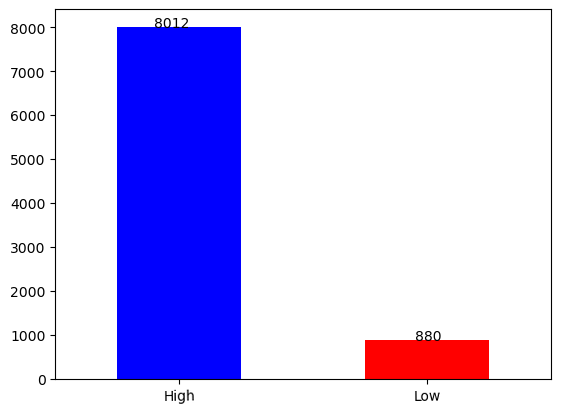

In [24]:
#ploting histogram
df['Rating_category'].value_counts().plot(kind='bar',rot=1,color=['blue','red'])
plt.text(x = -0.10, y = df.Rating_category.value_counts()[0]+2, s = df.Rating_category.value_counts()[0])
plt.text(x = 0.95, y = df.Rating_category.value_counts()[1], s = df.Rating_category.value_counts()[1])

In [25]:
#From the above bar garph we can that most them gave High Rating that is 8000+

# 8. Convert the column "Reviews'' to numeric data type and check the presence of outliers in the column and handle the outliers using a transformation approach.(Hint: Use log transformation)


In [26]:
#creating def function for checking numerice values and garbage values
def check_number(x):
    if x.isnumeric():
        return x
    else:
        print(x)

In [27]:
#Checking Reviews values any garbage values found or not using define function
df['Reviews'].apply(check_number)

0           159
1           967
2         87510
3        215644
4           967
          ...  
10834         7
10836        38
10837         4
10839       114
10840    398307
Name: Reviews, Length: 8892, dtype: object

In [28]:
#Changing Reviews as int
df['Reviews'] = df['Reviews'].astype(int)

In [29]:
df['Reviews']#reviews coloumn has been changed to int

0           159
1           967
2         87510
3        215644
4           967
          ...  
10834         7
10836        38
10837         4
10839       114
10840    398307
Name: Reviews, Length: 8892, dtype: int32

<Axes: ylabel='Reviews'>

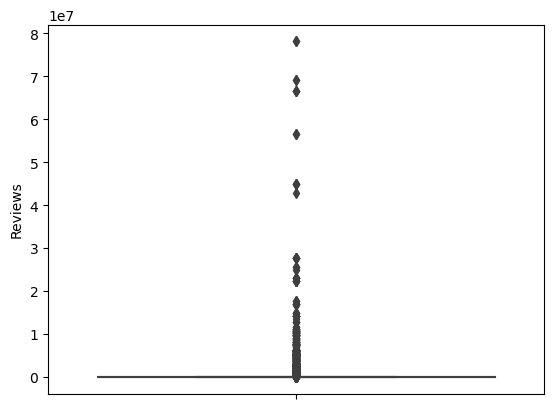

In [30]:
#creating boxplot for df['Reviews']
sns.boxplot(y=df['Reviews'])

In [31]:
#Outlier found in boxplot hence reduceing outliers useing log transform

In [32]:
 np.log1p(df['Reviews'])

0         5.075174
1         6.875232
2        11.379520
3        12.281389
4         6.875232
           ...    
10834     2.079442
10836     3.663562
10837     1.609438
10839     4.744932
10840    12.894981
Name: Reviews, Length: 8892, dtype: float64

In [33]:
df['Reviews'] = np.log1p(df['Reviews'])#log transform has done

<Axes: ylabel='Reviews'>

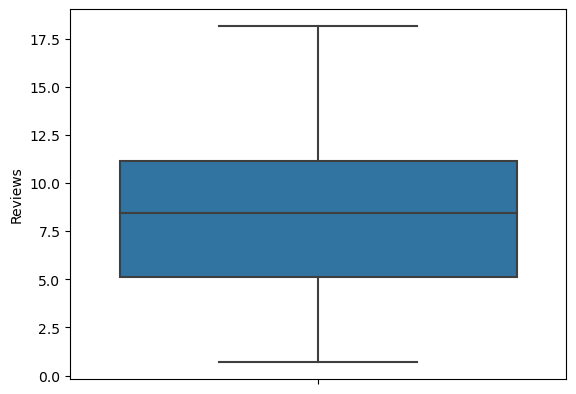

In [34]:
#creating another boxplot after log transform
sns.boxplot(y=df['Reviews'])
#outliers has been removed

# 9. The column 'Size' contains alphanumeric values, treat the non numeric data and convert the column into suitable data type. (hint: Replace M with 1 million and K with 1 thousand, and drop the entries where size='Varies with device')?



In [35]:
df['Size'].unique()

array(['19M', '14M', '8.7M', ..., '552k', '582k', '619k'], dtype=object)

In [36]:
#removeing rarbage values in Size that is 'Varies with device'
df = df[df["Size"]!='Varies with device']

In [37]:
#creating evaluate function to add or subtract or multiply it is Mathematical function
def evaluate(x):
    if type(x) is str:
        return eval(x)
    else:
        return x

In [38]:
#converting Size into float
df['Size'] = df['Size'].str.replace('M','*1000000').str.replace('k','*1000').apply(evaluate)

In [39]:
#df['Size'] has been converted into Float
df['Size']

0        19000000.0
1        14000000.0
2         8700000.0
3        25000000.0
4         2800000.0
            ...    
10833      619000.0
10834     2600000.0
10836    53000000.0
10837     3600000.0
10840    19000000.0
Name: Size, Length: 7424, dtype: float64

In [40]:
#Converting Size as int from float
df['Size'] = df['Size'].astype(int)

In [41]:
#df['Size'] has been changed into int
df['Size']

0        19000000
1        14000000
2         8700000
3        25000000
4         2800000
           ...   
10833      619000
10834     2600000
10836    53000000
10837     3600000
10840    19000000
Name: Size, Length: 7424, dtype: int32

# 10. Check the column 'Installs', treat the unwanted characters and convert the column into a suitable data type.?

In [42]:
#Checking 'Installs' type and converting it into proper numeric int or float by removeing unwanted characters
df['Installs']

0            10,000+
1           500,000+
2         5,000,000+
3        50,000,000+
4           100,000+
            ...     
10833         1,000+
10834           500+
10836         5,000+
10837           100+
10840    10,000,000+
Name: Installs, Length: 7424, dtype: object

In [43]:
#Checking unwanted characters from df['Installs']
df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000+', '500,000,000+', '100+', '500+', '10+', '1,000,000,000+',
       '5+', '50+', '1+'], dtype=object)

In [44]:
#Converting Installs as Float as int
df['Installs'] = df['Installs'].str.replace('+','').str.replace(',','').str.replace('Free','0').astype(int)


In [45]:
#df['Installs'] converted into int
df['Installs']

0           10000
1          500000
2         5000000
3        50000000
4          100000
           ...   
10833        1000
10834         500
10836        5000
10837         100
10840    10000000
Name: Installs, Length: 7424, dtype: int32

# 11. Check the column 'Price' , remove the unwanted characters and convert the column into a suitable data type.?

In [46]:
#Checking 'Price' type and converting it intyo proper numeric int or float by removeing unwanted characters
df['Price']

0        0
1        0
2        0
3        0
4        0
        ..
10833    0
10834    0
10836    0
10837    0
10840    0
Name: Price, Length: 7424, dtype: object

In [47]:
#Converting 'Price' as proper data type from Object
df['Price'] = df['Price'].str.replace('$','').astype(float)

In [48]:
#Price column has been converted to float
df['Price'].unique()

array([  0.  ,   4.99,   6.99,   7.99,   3.99,   5.99,   2.99,   1.99,
         9.99,   0.99,   9.  ,   5.49,  10.  ,  24.99,  11.99,  79.99,
        16.99,  14.99,  29.99,  12.99,   3.49,  10.99,   7.49,   1.5 ,
        19.99,  15.99,  33.99,  39.99,   2.49,   4.49,   1.7 ,   1.49,
         3.88, 399.99,  17.99, 400.  ,   3.02,   1.76,   4.84,   4.77,
         1.61,   1.59,   6.49,   1.29, 299.99, 379.99,  37.99,  18.99,
       389.99,   8.49,   1.75,  14.  ,   2.  ,   3.08,   2.59,  19.4 ,
        15.46,   8.99,   3.04,  13.99,   4.29,   3.28,   4.6 ,   1.  ,
         2.9 ,   1.97,   2.56,   1.2 ])

# 12. Drop the columns which you think redundant for the analysis.(suggestion: drop column 'rating', since we created a new feature from it (i.e. rating_category) and the columns 'App', 'Rating' ,'Genres','Last Updated', 'Current Ver','Android Ver' columns since which are redundant for our analysis)?



In [49]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Rating_category'],
      dtype='object')

In [50]:
## Droping unwanted columns
df.drop(['App','Last Updated','Current Ver','Android Ver','Rating','Genres'],axis=1,inplace=True)

In [51]:
df.head(2)#unwanted columns are removed

,Category,Reviews,Size,Installs,Type,Price,Content Rating,Rating_category
0,ART_AND_DESIGN,5.075174,19000000,10000,Free,0.0,Everyone,High
1,ART_AND_DESIGN,6.875232,14000000,500000,Free,0.0,Everyone,High


In [64]:
df.describe()

,Reviews,Size,Installs,Price,Rating_category,Category_ART_AND_DESIGN,Category_AUTO_AND_VEHICLES,Category_BEAUTY,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,...,Category_VIDEO_PLAYERS,Category_WEATHER,Content Rating_Adults only 18+,Content Rating_Everyone,Content Rating_Everyone 10+,Content Rating_Mature 17+,Content Rating_Teen,Content Rating_Unrated,Type_Free,Type_Paid
count,7424.000000,7.424000e+03,7.424000e+03,7424.000000,7424.000000,7424.000000,7424.000000,7424.000000,7424.000000,7424.000000,...,7424.000000,7424.000000,7424.000000,7424.000000,7424.000000,7424.000000,7424.000000,7424.000000,7424.000000,7424.000000
mean,7.636580,2.274762e+07,7.823918e+06,1.116599,0.888874,0.007947,0.008486,0.004984,0.019262,0.030307,...,0.015625,0.006870,0.000269,0.802532,0.040275,0.044720,0.112069,0.000135,0.926320,0.073680
std,3.689193,2.343479e+07,4.630411e+07,17.708566,0.314309,0.088798,0.091734,0.070425,0.137453,0.171443,...,0.124028,0.082604,0.016412,0.398115,0.196616,0.206702,0.315473,0.011606,0.261267,0.261267
min,0.693147,8.500000e+03,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.605170,5.100000e+06,1.000000e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,7.634337,1.400000e+07,1.000000e+05,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,10.515852,3.300000e+07,1.000000e+06,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,17.619812,1.000000e+08,1.000000e+09,400.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 13.Encode the categorical columns.?

In [52]:
df = pd.get_dummies(df,columns=['Category','Content Rating','Type'])
# Categorical columns has been encoded with boolean values 0 and 1 by creating new column useing ONE HOT Encoding method

In [53]:
df.head(2)

,Reviews,Size,Installs,Price,Rating_category,Category_ART_AND_DESIGN,Category_AUTO_AND_VEHICLES,Category_BEAUTY,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,...,Category_VIDEO_PLAYERS,Category_WEATHER,Content Rating_Adults only 18+,Content Rating_Everyone,Content Rating_Everyone 10+,Content Rating_Mature 17+,Content Rating_Teen,Content Rating_Unrated,Type_Free,Type_Paid
0,5.075174,19000000,10000,0.0,High,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,6.875232,14000000,500000,0.0,High,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0


# 14. Segregate the target and independent features (Hint: Use Rating_category as the target)?

In [54]:
#Dropping Target value 
df.drop('Rating_category' ,axis=1)

,Reviews,Size,Installs,Price,Category_ART_AND_DESIGN,Category_AUTO_AND_VEHICLES,Category_BEAUTY,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMICS,...,Category_VIDEO_PLAYERS,Category_WEATHER,Content Rating_Adults only 18+,Content Rating_Everyone,Content Rating_Everyone 10+,Content Rating_Mature 17+,Content Rating_Teen,Content Rating_Unrated,Type_Free,Type_Paid
0,5.075174,19000000,10000,0.0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,6.875232,14000000,500000,0.0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,11.379520,8700000,5000000,0.0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,12.281389,25000000,50000000,0.0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
4,6.875232,2800000,100000,0.0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10833,3.806662,619000,1000,0.0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
10834,2.079442,2600000,500,0.0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
10836,3.663562,53000000,5000,0.0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
10837,1.609438,3600000,100,0.0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0


In [55]:
#Droping target value
X = df.drop('Rating_category' ,axis=1)

In [56]:
# Hence 'Rating_category' is a target value converting it into boolean values as 0 and 1
df[['Rating_category']] = df[['Rating_category']].replace({'High':1 ,'Low':0})

In [57]:
#Storing target value in 'y' variable
y = df[['Rating_category']]

# 15. Split the dataset into train and test.?

In [58]:
#Spliting the dataset into 2 dependent and independent as x,y 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30 , random_state=1)

# 16. Standardize the data, so that the values are within a particular range.?

In [59]:
#Standardizeing the data useing standardscaler method from sklearn so that values will be in  1-3

In [60]:
#Scales the data. Essentially returns the z-scores of every attribute

from sklearn.preprocessing import StandardScaler

std_scale = StandardScaler()

std_scale

StandardScaler()

In [61]:
X_train.iloc[:,0:4] = std_scale.fit_transform(X_train.iloc[:,0:4])
## Standardscaleing done only to columns 'Reviews,Size, installs, price' rest all columns done encoded

In [62]:
X_train#Standardscaleing has be completed

,Reviews,Size,Installs,Price,Category_ART_AND_DESIGN,Category_AUTO_AND_VEHICLES,Category_BEAUTY,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMICS,...,Category_VIDEO_PLAYERS,Category_WEATHER,Content Rating_Adults only 18+,Content Rating_Everyone,Content Rating_Everyone 10+,Content Rating_Mature 17+,Content Rating_Teen,Content Rating_Unrated,Type_Free,Type_Paid
8888,-1.875679,-0.855591,-0.167505,-0.061474,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1298,1.209660,1.439900,-0.063664,-0.061474,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
6599,-0.514017,-0.728299,-0.167299,-0.061474,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
7328,-0.614074,-0.719813,-0.167403,0.182656,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
5681,-0.966551,-0.732542,-0.167299,-0.061474,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1522,-0.364175,3.221981,-0.166468,-0.061474,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
7755,-1.144539,0.591290,-0.167486,-0.061474,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
5978,-1.875679,-0.893778,-0.167506,0.029693,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
347,2.089907,-0.511904,10.216797,-0.061474,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
